# Comparing models with confidence intervals

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from itertools import product

In [2]:
ds_lstm = xr.open_dataset("../data/processed/CI/mse_LSTM_n05.nc")
ds_phys = xr.open_dataset("../data/processed/CI/mse_physical_model_n05.nc")
ds_boost = xr.open_dataset("../data/processed/CI/mse_boosted_model_n05.nc")

In [4]:
ds_lstm, ds_phys, ds_boost = xr.align(
    ds_lstm, ds_phys, ds_boost, join="exact"
)


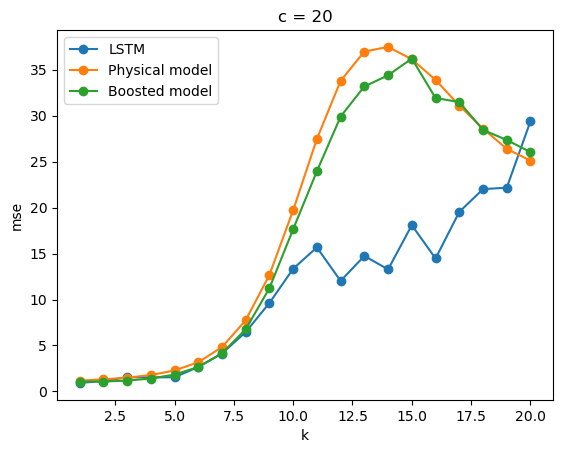

In [6]:
fig, ax = plt.subplots()


ds_lstm.mse.plot(marker="o", label="LSTM")
ds_phys.mse.sel(c=20).plot(marker="o",label="Physical model")
ds_boost.mse.sel(c=20).plot(marker="o",label="Boosted model")

ax.legend()

In [22]:
from pathlib import Path

FIGURES = Path("../figures/boosting/CI/log-noise-05")
FIGURES.mkdir(parents=True, exist_ok=True)

In [23]:
# Choose c value
xticks = [1,5,10,15,20]
c_val = 20

for c_val in np.arange(10,21):
  fig, ax = plt.subplots()

  # ----- LSTM model (no c dimension) -----
  mean = ds_lstm["mse"]
  lower = ds_lstm["ci_lower"]
  upper = ds_lstm["ci_upper"]

  plt.plot(ds_lstm.k, mean, marker='o', label="LSTM")
  plt.fill_between(ds_lstm.k, lower, upper, alpha=0.2)

  # ----- Physical model -----
  mean = ds_phys["mse"].sel(c=c_val)
  lower = ds_phys["ci_lower"].sel(c=c_val)
  upper = ds_phys["ci_upper"].sel(c=c_val)

  plt.plot(ds_phys.k, mean, marker='o', label="Physical model")
  plt.fill_between(ds_phys.k, lower, upper, alpha=0.2)

  # ----- Boosted model -----
  mean = ds_boost["mse"].sel(c=c_val)
  lower = ds_boost["ci_lower"].sel(c=c_val)
  upper = ds_boost["ci_upper"].sel(c=c_val)

  plt.plot(ds_boost.k, mean, marker='o', label="Boosted model")
  plt.fill_between(ds_boost.k, lower, upper, alpha=0.2)


  plt.xlabel("Forecast Horizon")
  plt.ylabel("MSE")
  # plt.title(f"MSE ± 95% CI (c = {c_val})")
  plt.legend()
  ax.set_xticks(xticks)
  plt.yscale("log")
  # plt.show()
  fig.savefig(FIGURES / f"mse_vs_k_c{c_val}.png", dpi=300, bbox_inches="tight")
  plt.close(fig)  